# Module 7 · Lab 7.3 — Parallelization: Fan-Out / Fan-In with the Send API
## Concurrent workers merged deterministically with reducers

**Scenario.** Real-world parallel processing for a **financial compliance pipeline**. We progress from a baseline linear graph through static fan-out to dynamic fan-out with the `Send` API — and finish with an **empirical cost / latency comparison**.

**Learning Objectives.** By the end of this lab, you will be able to:
1. Build a baseline **linear graph** and observe the wall-clock time for sequential nodes.
2. Use **multiple outgoing edges from one node** to express **static fan-out / fan-in** with reducers.
3. Apply the LangGraph **`Send` API** for **dynamic fan-out** when the worker count is data-dependent.
4. Wire **fan-in reducers** (`operator.add`, custom merge functions) to deterministically combine concurrent updates.
5. Empirically measure the speedup of 4 parallel LLM calls vs 4 sequential calls — and articulate when parallelization is NOT a win.

**Tools.** LangGraph v1 · LangChain v1 · `langchain-openai` · `gpt-4.1-mini`.


---


> 🗺️ **Workshop run-list.**
> **Live in session:** Part 2 static fan-out / fan-in, Part 4 parallel compliance checks, Part 5 dynamic fan-out with `Send` ⭐ (the mechanism behind your capstone), Part 6 measured cost and latency, §7
> **After the session:** Part 1 the linear baseline and Part 3 uneven paths (read them), §8, interview preparation — kept in full so you can finish at your own pace (marked ⏭️).

## Setup: Install Dependencies

In [1]:
# 📦 Packages this notebook needs. On the workshop VM they are pre-installed from
# the workshop's requirements.txt, so the install line below stays commented out.
# Running somewhere else (Colab, your own laptop)? Uncomment it and run this cell once.
# !pip install -qU langchain langchain-core langchain-openai langgraph python-dotenv

from importlib.metadata import PackageNotFoundError, version

NOTEBOOK_PACKAGES = [
    "langchain",
    "langchain-core",
    "langchain-openai",
    "langgraph",
    "python-dotenv",
]
for package_name in NOTEBOOK_PACKAGES:
    try:
        print(f"{package_name:<26} {version(package_name)}")
    except PackageNotFoundError:
        print(f"{package_name:<26} NOT INSTALLED — uncomment the !pip line above")

langchain                  1.4.3
langchain-core             1.6.6
langchain-openai           1.6.6
langgraph                  1.2.12
python-dotenv              1.2.3


In [2]:
import os

# Where to create each key. The trainer supplies OPENAI_API_KEY on the workshop VM;
# you create any other key yourself and add it to the workshop's .env file as KEY_NAME=value.
KEY_SIGNUP_PAGES = {
    "OPENAI_API_KEY": "supplied on the workshop VM (elsewhere: https://platform.openai.com/api-keys)",
    "TAVILY_API_KEY": "https://app.tavily.com (free tier)",
    "GROQ_API_KEY": "https://console.groq.com/keys (free tier)",
    "WEATHER_API_KEY": "https://www.weatherapi.com/signup.aspx (free tier)",
    "LANGSMITH_API_KEY": "https://smith.langchain.com -> Settings -> API Keys (free tier)",
    "ANTHROPIC_API_KEY": "https://console.anthropic.com/settings/keys",
    "GEMINI_API_KEY": "https://aistudio.google.com/app/apikey",
}


def load_keys(required):
    """Load API keys from Colab Secrets (on Colab) or a local .env file (elsewhere).

    Prints one line per key, then stops with instructions if a required key is missing.

    Args:
        required: the environment-variable names this lab needs.
    """
    try:
        from google.colab import userdata          # running on Google Colab
        for key_name in required:
            try:
                os.environ[key_name] = userdata.get(key_name)
            except Exception:
                pass                                 # not set in Colab Secrets
        source = "Colab Secrets"
    except ImportError:                              # the workshop VM, or any local machine
        from dotenv import find_dotenv, load_dotenv
        load_dotenv(find_dotenv(usecwd=True))        # searches upward for the workshop's .env file
        source = ".env / environment"
    print(f"\U0001F511 Key source: {source}")
    for key_name in required:
        print(f"   {key_name:<22} {'✅' if os.environ.get(key_name) else '❌ MISSING'}")
    missing_keys = [key_name for key_name in required if not os.environ.get(key_name)]
    if missing_keys:
        instructions = "\n".join(
            f"  {key_name}: {KEY_SIGNUP_PAGES.get(key_name, 'see README.md in the workshop folder')}"
            for key_name in missing_keys)
        raise RuntimeError(
            "This lab needs API keys that are not set yet. Create each one, add it to\n"
            "the workshop's .env file as KEY_NAME=value, then re-run this cell:\n" + instructions)

load_keys(["OPENAI_API_KEY"])

🔑 Key source: .env / environment
   OPENAI_API_KEY         ✅


## Import Libraries

In [3]:
import operator
from typing import Any, Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

> ⏭️ **After the session.** This section is not run live in the workshop. Work through it afterwards, top to bottom.

## Part 1: Simple Linear Graph (Baseline)

Before parallelizing, let's build a simple sequential graph where steps execute one after another: **A -> B -> C -> D**. This establishes the baseline pattern.

We define:
- A `State` with `Annotated[list, operator.add]` so values accumulate across nodes
- A `ReturnNodeValue` helper class that each node uses to append its value to state

In [4]:
# Define State with a reducer that concatenates lists
class State(TypedDict):
    """Graph state: one list that every node appends to, merged by operator.add."""
    state: Annotated[list, operator.add]

# Helper class — each node appends its value to the shared state list
class ReturnNodeValue:
    """A demo node that appends a fixed marker to the state, so execution order shows."""
    def __init__(self, node_secret: str):
        """Remember the marker this node will append."""
        self._value = node_secret

    def __call__(self, state: State) -> Any:
        """Print the state so far and return this node's marker as an update."""
        print(f"Adding '{self._value}' to {state['state']}")
        return {"state": [self._value]}

### Build the Linear Graph: START -> A -> B -> C -> D -> END

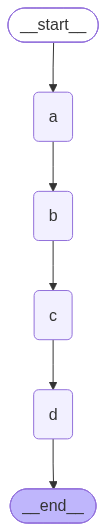

In [5]:
# Build a simple linear graph: A -> B -> C -> D
builder = StateGraph(State)

# Add nodes
builder.add_node("a", ReturnNodeValue("step A"))
builder.add_node("b", ReturnNodeValue("step B"))
builder.add_node("c", ReturnNodeValue("step C"))
builder.add_node("d", ReturnNodeValue("step D"))

# Add edges — strictly sequential
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("b", "c")
builder.add_edge("c", "d")
builder.add_edge("d", END)

# Compile and visualize
linear_graph = builder.compile()
display(Image(linear_graph.get_graph().draw_mermaid_png()))

### Run the Linear Graph

All four steps execute sequentially. Notice the order is always A, B, C, D.

In [6]:
# Invoke the linear graph
result = linear_graph.invoke({"state": []})
print("\nFinal state:", result["state"])

Adding 'step A' to []
Adding 'step B' to ['step A']
Adding 'step C' to ['step A', 'step B']
Adding 'step D' to ['step A', 'step B', 'step C']

Final state: ['step A', 'step B', 'step C', 'step D']


## Part 2: Fan-Out / Fan-In Pattern

Now let's run steps B and C in **parallel** after A, then merge into D:

```
A -> B \
       -> D
A -> C /
```

The key is adding **two edges from A** (fan-out) and **two edges to D** (fan-in). LangGraph automatically runs B and C simultaneously because they have no dependency on each other.

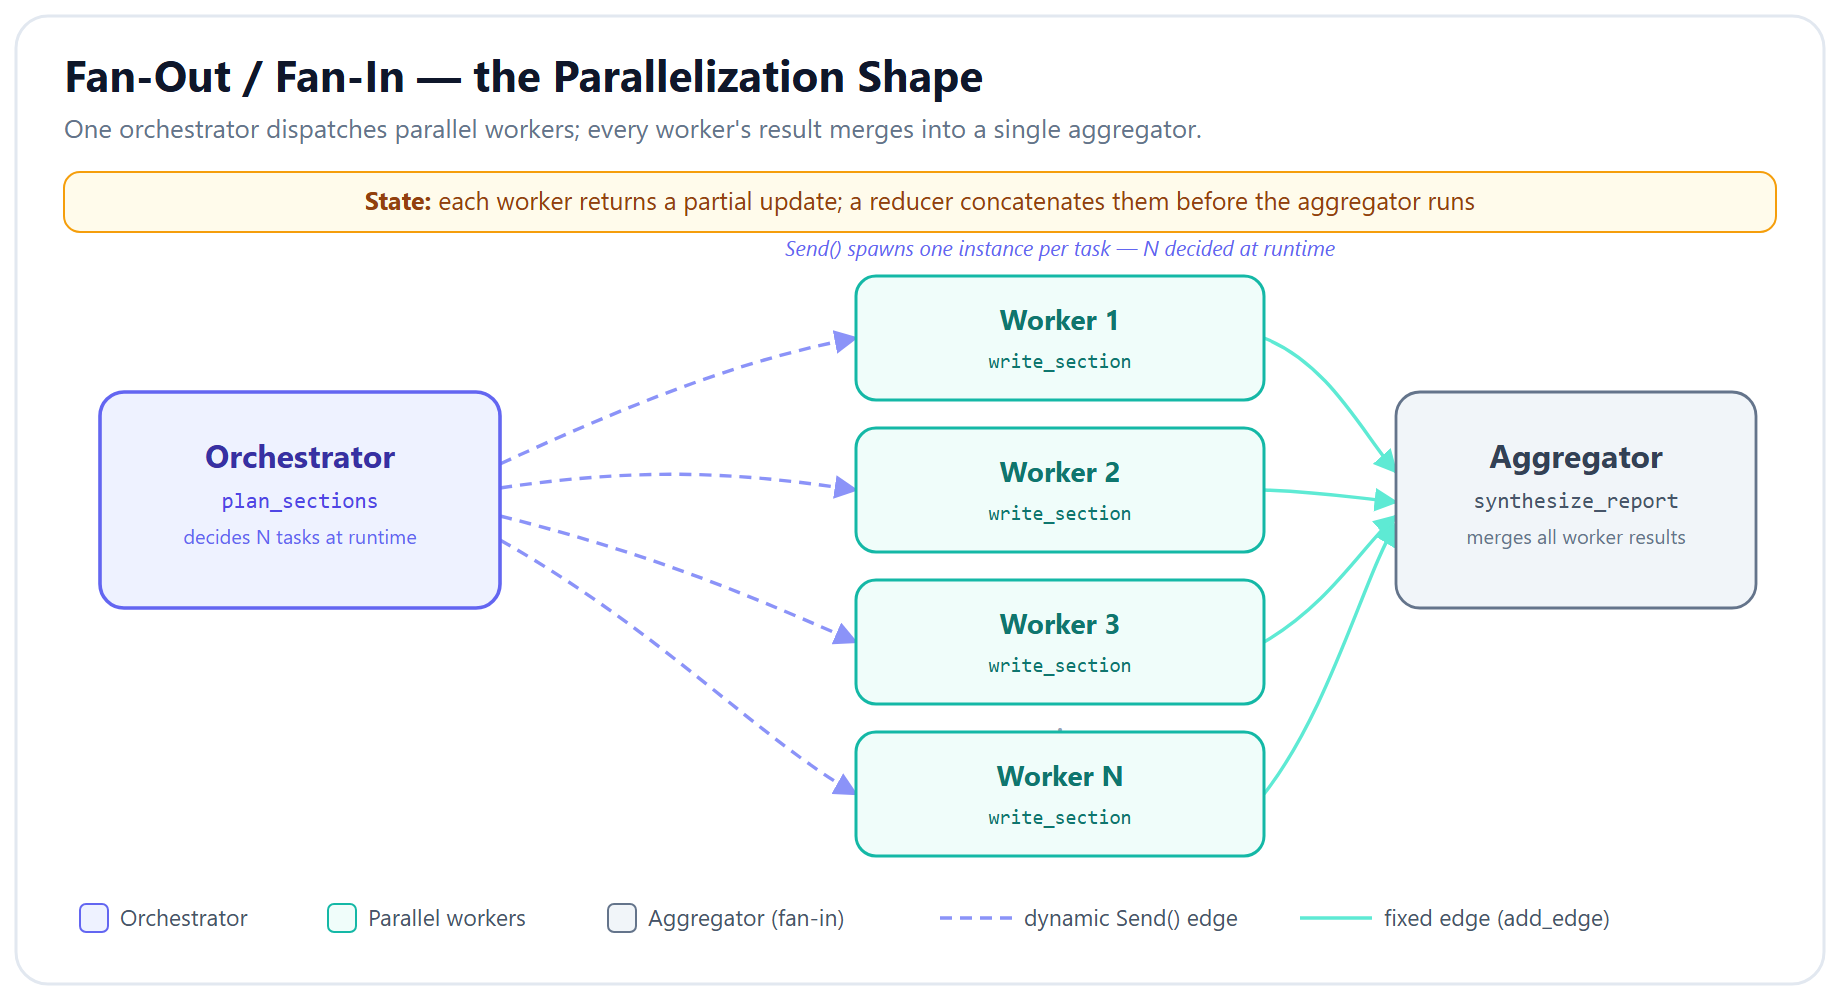

**Figure — Fan-out / fan-in parallelization shape.** An `orchestrator` dispatches N parallel workers; every worker's result merges into a single `aggregator` — the shape behind LangGraph's Send-based parallelization.

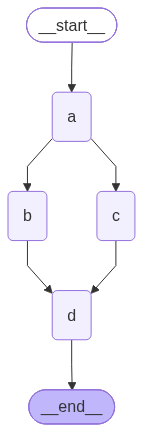

In [7]:
# Build the fan-out / fan-in graph
builder = StateGraph(State)

# Add nodes
builder.add_node("a", ReturnNodeValue("step A"))
builder.add_node("b", ReturnNodeValue("step B"))
builder.add_node("c", ReturnNodeValue("step C"))
builder.add_node("d", ReturnNodeValue("step D"))

# Edges
builder.add_edge(START, "a")
builder.add_edge("a", "b")  # Fan-out: A feeds B
builder.add_edge("a", "c")  # Fan-out: A feeds C simultaneously
builder.add_edge("b", "d")  # Fan-in: B feeds D
builder.add_edge("c", "d")  # Fan-in: C feeds D
builder.add_edge("d", END)

# Compile and visualize
fanout_graph = builder.compile()
display(Image(fanout_graph.get_graph().draw_mermaid_png()))

### Run the Fan-Out / Fan-In Graph

B and C run in parallel. Their order in the final list may vary across runs — that's expected with parallel execution!

In [8]:
# Invoke the fan-out graph
result = fanout_graph.invoke({"state": []})
print("\nFinal state:", result["state"])

Adding 'step A' to []
Adding 'step B' to ['step A']
Adding 'step C' to ['step A']
Adding 'step D' to ['step A', 'step B', 'step C']

Final state: ['step A', 'step B', 'step C', 'step D']


> ⏭️ **After the session.** This section is not run live in the workshop. Work through it afterwards, top to bottom.

## Part 3: Uneven Parallel Paths

What if one parallel path has more steps than the other? LangGraph handles this by waiting for **all** parallel paths to complete before proceeding to the fan-in node.

```
A -> B -> X \
            -> D
A -> C     /
```

Path 1 (A -> B -> X) takes 2 steps while Path 2 (A -> C) takes 1 step. Node D waits for **both** paths to finish.

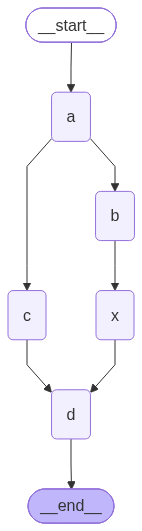

In [9]:
# Build the uneven parallel paths graph
builder = StateGraph(State)

# Add nodes — note the extra node "x" on one path
builder.add_node("a", ReturnNodeValue("step A"))
builder.add_node("b", ReturnNodeValue("step B"))
builder.add_node("x", ReturnNodeValue("step X"))
builder.add_node("c", ReturnNodeValue("step C"))
builder.add_node("d", ReturnNodeValue("step D"))

# Edges
builder.add_edge(START, "a")
builder.add_edge("a", "b")  # Path 1: A -> B
builder.add_edge("b", "x")  # Path 1: B -> X
builder.add_edge("a", "c")  # Path 2: A -> C (shorter path)
builder.add_edge("x", "d")  # Fan-in: X feeds D
builder.add_edge("c", "d")  # Fan-in: C feeds D
builder.add_edge("d", END)

# Compile and visualize
uneven_graph = builder.compile()
display(Image(uneven_graph.get_graph().draw_mermaid_png()))

### Run the Uneven Graph

D only runs after both paths complete. C finishes first (1 step), but D waits for X (2 steps) too.

In [10]:
# Invoke the uneven graph
result = uneven_graph.invoke({"state": []})
print("\nFinal state:", result["state"])

Adding 'step A' to []
Adding 'step B' to ['step A']
Adding 'step C' to ['step A']
Adding 'step D' to ['step A', 'step B', 'step C']
Adding 'step X' to ['step A', 'step B', 'step C']
Adding 'step D' to ['step A', 'step B', 'step C', 'step D', 'step X']

Final state: ['step A', 'step B', 'step C', 'step D', 'step X', 'step D']


## Part 4: Real-World Parallel Processing — Financial Compliance

### Business Scenario: SecureBank Transaction Monitoring

SecureBank India is a mid-size private bank that must check every high-value transaction (above INR 10 lakh) against multiple risk models before approving it. The bank's compliance department has identified four independent checks:

1. **AML Check (Anti-Money Laundering)**: Analyzes transaction patterns for money laundering indicators — structuring, round amounts, rapid movement of funds. Based on RBI Master Direction on KYC/AML compliance.

2. **Fraud Pattern Detection**: Checks for behavioral anomalies — unusual transaction amounts compared to customer history, sudden changes in transaction patterns, or transactions outside normal geographic regions.

3. **Sanctions Screening**: Verifies that neither the sender nor receiver appears on sanctions lists (OFAC, UN, India's UAPA) or is associated with flagged entities.

4. **Velocity Check**: Monitors transaction frequency — flags accounts with unusually high numbers of transactions in a short period, which may indicate automated fraud or structuring.

These four checks are **independent** — each can run without waiting for the others. Running them sequentially takes ~8 seconds (four ~2-second checks — illustrative numbers). Running them in parallel takes ~2 seconds (the time of the slowest check). Part 6 measures the real ratio.

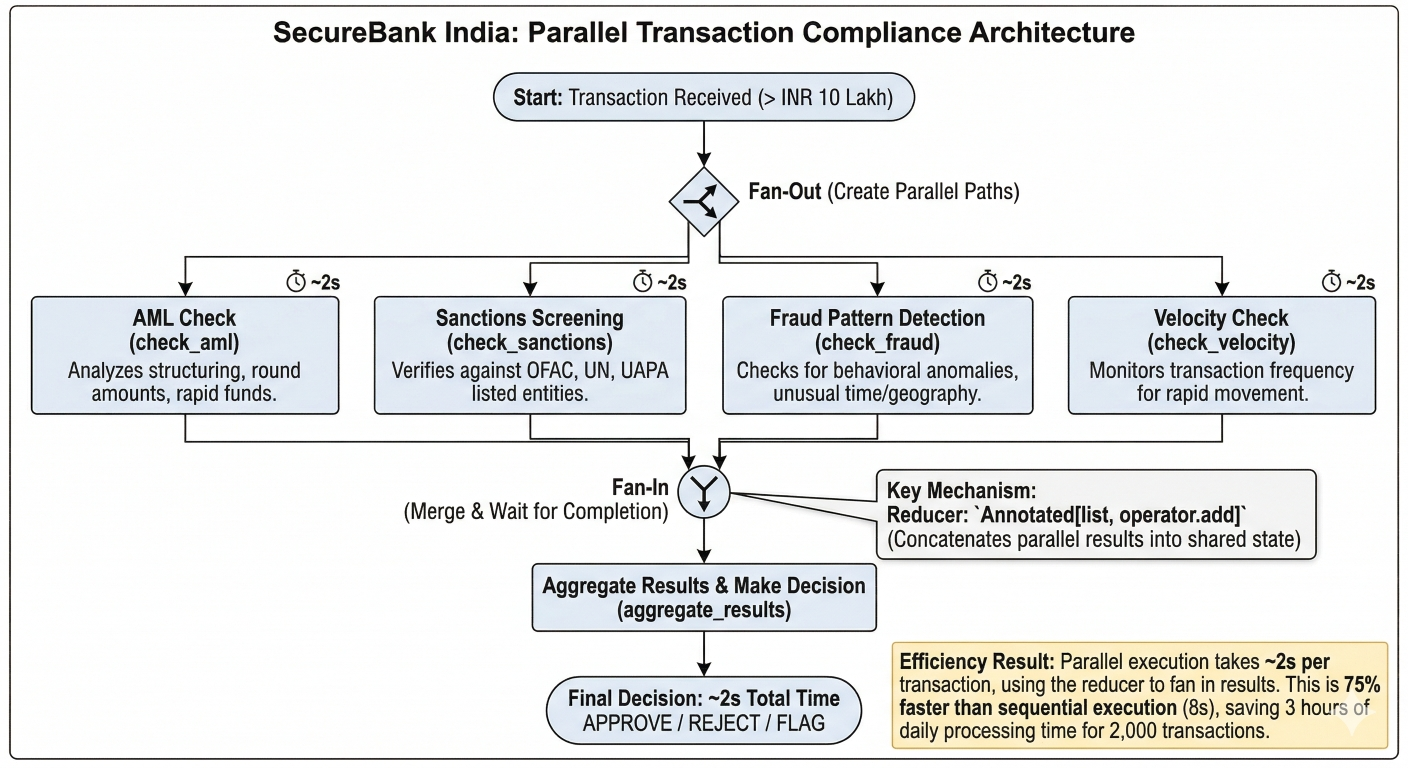

### Initialize LLM and Define AgentState

In [11]:
import os
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

# Initialize the LLM
chat_model = ChatOpenAI(model="gpt-4.1-mini", temperature=0.3)

# Define the AgentState for our compliance checker
class AgentState(TypedDict):
    """Compliance-check state: one transaction and the results of every parallel check."""
    transaction: dict                                # Input transaction data
    risk_results: Annotated[list, operator.add]      # Reducer: collects parallel check results
    overall_risk: str                                # Final aggregated risk level
    decision: str                                    # Final approve/reject decision

### Create Sample Transactions

Three transactions with varying risk profiles for testing.

In [12]:
# Sample transactions with different risk profiles
transactions = [
    {
        "id": "TXN-2025-001",
        "sender": "Rajesh Mehta",
        "sender_account": "SBKIN0012345678",
        "receiver": "Priya Sharma",
        "receiver_account": "HDFCIN0087654321",
        "amount": 1500000,  # INR 15 lakh
        "currency": "INR",
        "type": "NEFT",
        "timestamp": "2025-03-15T14:30:00",
        "sender_city": "Mumbai",
        "receiver_city": "Delhi",
        "description": "Property advance payment",
        "sender_avg_monthly_txn": 200000,
        "txn_count_last_24h": 2,
    },
    {
        "id": "TXN-2025-002",
        "sender": "Global Trade LLC",
        "sender_account": "ICICIN0099887766",
        "receiver": "Offshore Holdings Ltd",
        "receiver_account": "SWIFT-CAYMAN-4422",
        "amount": 5000000,  # INR 50 lakh — round amount
        "currency": "INR",
        "type": "RTGS",
        "timestamp": "2025-03-15T23:55:00",  # Late night
        "sender_city": "Chennai",
        "receiver_city": "Cayman Islands",
        "description": "Consulting fees",
        "sender_avg_monthly_txn": 800000,
        "txn_count_last_24h": 12,  # High frequency
    },
    {
        "id": "TXN-2025-003",
        "sender": "Anita Desai",
        "sender_account": "AXISIN0011223344",
        "receiver": "Sunrise Hospital",
        "receiver_account": "KOTAK0055667788",
        "amount": 1200000,  # INR 12 lakh
        "currency": "INR",
        "type": "IMPS",
        "timestamp": "2025-03-15T10:15:00",
        "sender_city": "Bangalore",
        "receiver_city": "Bangalore",
        "description": "Medical emergency - surgery payment",
        "sender_avg_monthly_txn": 300000,
        "txn_count_last_24h": 1,
    },
]

print(f"Created {len(transactions)} test transactions")
for transaction in transactions:
    print(f"  {transaction['id']}: INR {transaction['amount']:,.0f} from {transaction['sender']} to {transaction['receiver']}")

Created 3 test transactions
  TXN-2025-001: INR 1,500,000 from Rajesh Mehta to Priya Sharma
  TXN-2025-002: INR 5,000,000 from Global Trade LLC to Offshore Holdings Ltd
  TXN-2025-003: INR 1,200,000 from Anita Desai to Sunrise Hospital


### Create Node Functions for Compliance Checking

Each function below represents a step in the compliance checking pipeline:

1. **check_aml**: Analyzes transaction for anti-money laundering indicators
2. **check_fraud**: Checks for behavioral anomalies and fraud patterns
3. **check_sanctions**: Screens against sanctions lists
4. **check_velocity**: Monitors transaction frequency patterns
5. **aggregate_results**: Combines all parallel risk results and makes a decision

In [13]:
def check_aml(state: AgentState) -> dict:
    """Analyze transaction for anti-money laundering indicators."""
    prompt = ChatPromptTemplate.from_template("""
You are an AML compliance analyst at SecureBank India.
Analyze this transaction for money laundering indicators:

Transaction: {transaction}

Check for: structuring, round amounts, rapid fund movement, layering.
Respond with a brief risk assessment (2-3 sentences) and risk level (LOW/MEDIUM/HIGH).
Format: RISK LEVEL: <level> | ANALYSIS: <your assessment>
""")
    chain = prompt | chat_model
    result = chain.invoke({"transaction": str(state["transaction"])}).content
    print(f"[AML Check Complete]")
    return {"risk_results": [{"check": "AML", "result": result}]}


def check_fraud(state: AgentState) -> dict:
    """Check for behavioral anomalies and fraud patterns."""
    prompt = ChatPromptTemplate.from_template("""
You are a fraud detection specialist at SecureBank India.
Analyze this transaction for fraud indicators:

Transaction: {transaction}

Check for: unusual amount vs. customer history, time-of-day anomalies, geographic irregularities.
Respond with a brief risk assessment (2-3 sentences) and risk level (LOW/MEDIUM/HIGH).
Format: RISK LEVEL: <level> | ANALYSIS: <your assessment>
""")
    chain = prompt | chat_model
    result = chain.invoke({"transaction": str(state["transaction"])}).content
    print(f"[Fraud Check Complete]")
    return {"risk_results": [{"check": "Fraud", "result": result}]}


def check_sanctions(state: AgentState) -> dict:
    """Screen against sanctions lists."""
    prompt = ChatPromptTemplate.from_template("""
You are a sanctions screening officer at SecureBank India.
Screen this transaction against known sanctions lists:

Transaction: {transaction}

Check for: OFAC, UN, UAPA listed entities, offshore jurisdiction risks, shell company indicators.
Respond with a brief risk assessment (2-3 sentences) and risk level (LOW/MEDIUM/HIGH).
Format: RISK LEVEL: <level> | ANALYSIS: <your assessment>
""")
    chain = prompt | chat_model
    result = chain.invoke({"transaction": str(state["transaction"])}).content
    print(f"[Sanctions Check Complete]")
    return {"risk_results": [{"check": "Sanctions", "result": result}]}


def check_velocity(state: AgentState) -> dict:
    """Monitor transaction frequency patterns."""
    prompt = ChatPromptTemplate.from_template("""
You are a transaction monitoring analyst at SecureBank India.
Analyze the velocity pattern of this transaction:

Transaction: {transaction}

Check for: unusual transaction frequency, rapid successive transfers, structuring patterns.
Respond with a brief risk assessment (2-3 sentences) and risk level (LOW/MEDIUM/HIGH).
Format: RISK LEVEL: <level> | ANALYSIS: <your assessment>
""")
    chain = prompt | chat_model
    result = chain.invoke({"transaction": str(state["transaction"])}).content
    print(f"[Velocity Check Complete]")
    return {"risk_results": [{"check": "Velocity", "result": result}]}


def aggregate_results(state: AgentState) -> dict:
    """Combine all parallel risk results and make a final decision."""
    prompt = ChatPromptTemplate.from_template("""
You are the Chief Compliance Officer at SecureBank India.
Review all risk assessment results and make a final decision.

Transaction: {transaction}

Risk Assessment Results:
{risk_results}

Based on ALL the above checks, provide:
1. OVERALL RISK LEVEL (LOW / MEDIUM / HIGH)
2. DECISION (APPROVE / FLAG FOR REVIEW / REJECT)
3. Brief justification (2-3 sentences)

Format:
OVERALL RISK: <level>
DECISION: <decision>
JUSTIFICATION: <your reasoning>
""")
    chain = prompt | chat_model
    # Format risk results for the prompt
    results_text = "\n".join(
        [f"- {risk_result['check']}: {risk_result['result']}" for risk_result in state["risk_results"]]
    )
    result = chain.invoke({
        "transaction": str(state["transaction"]),
        "risk_results": results_text
    }).content
    print(f"[Aggregation Complete]")
    return {"overall_risk": result, "decision": result}

print("All node functions defined successfully.")

All node functions defined successfully.


### Build the Parallel Compliance Graph

Fan-out from START to all 4 checks, then fan-in to aggregate_results.

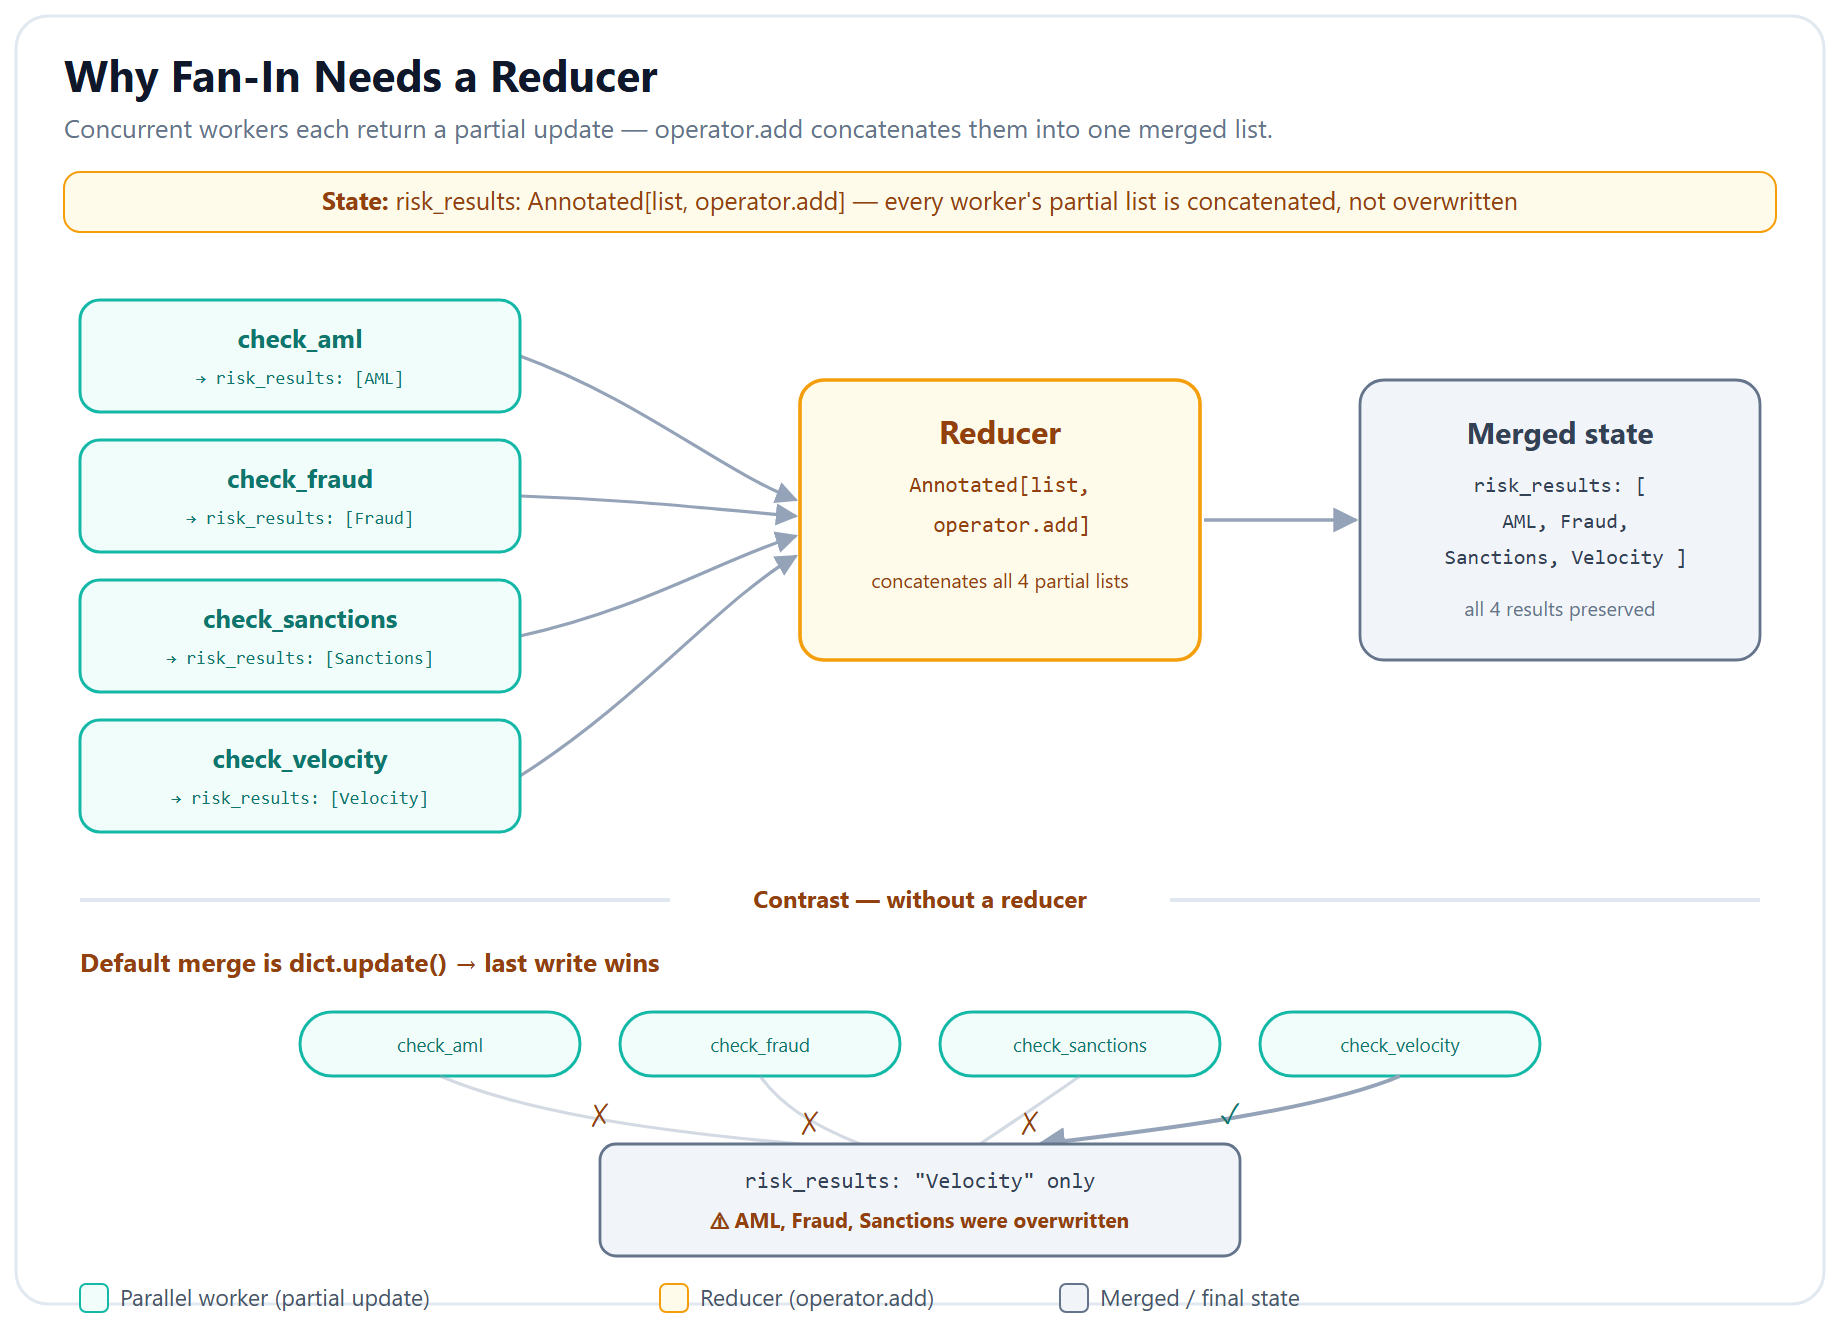

**Figure — Why fan-in needs a reducer.** Four parallel checks each return a partial `risk_results` list; `Annotated[list, operator.add]` concatenates them — without a reducer, the default `dict.update()` lets the last-finishing worker silently overwrite the rest.

In [14]:
# Build the parallel compliance checking graph
compliance_builder = StateGraph(AgentState)

# Add all nodes
compliance_builder.add_node("check_aml", check_aml)
compliance_builder.add_node("check_fraud", check_fraud)
compliance_builder.add_node("check_sanctions", check_sanctions)
compliance_builder.add_node("check_velocity", check_velocity)
compliance_builder.add_node("aggregate_results", aggregate_results)

# Fan-out: START feeds all 4 checks in parallel
compliance_builder.add_edge(START, "check_aml")
compliance_builder.add_edge(START, "check_fraud")
compliance_builder.add_edge(START, "check_sanctions")
compliance_builder.add_edge(START, "check_velocity")

# Fan-in: all 4 checks feed into aggregate_results
compliance_builder.add_edge("check_aml", "aggregate_results")
compliance_builder.add_edge("check_fraud", "aggregate_results")
compliance_builder.add_edge("check_sanctions", "aggregate_results")
compliance_builder.add_edge("check_velocity", "aggregate_results")

# Aggregate results lead to END
compliance_builder.add_edge("aggregate_results", END)

# Compile
compliance_graph = compliance_builder.compile()
print("Compliance graph compiled successfully.")

Compliance graph compiled successfully.


### Visualize the Compliance Graph

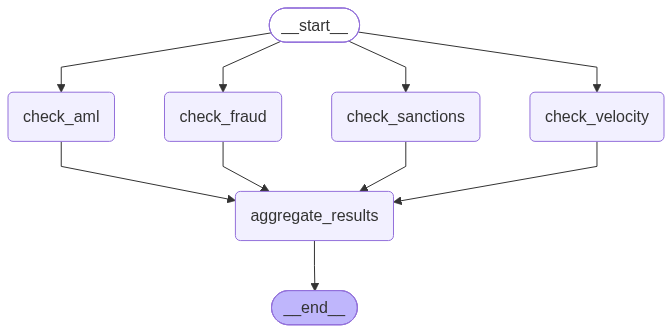

In [15]:
# Visualize the parallel compliance graph
display(Image(compliance_graph.get_graph().draw_mermaid_png()))

### Run Compliance Checks on All Transactions

We process all 3 transactions through the parallel compliance pipeline and display results.

In [16]:
# Process each transaction through the compliance pipeline
for transaction in transactions:
    print("=" * 80)
    print(f"Processing: {transaction['id']} | INR {transaction['amount']:,.0f} | {transaction['sender']} -> {transaction['receiver']}")
    print("=" * 80)

    result = compliance_graph.invoke({
        "transaction": transaction,
        "risk_results": [],
    })

    # Display individual check results
    print("\n--- Individual Check Results ---")
    for check_result in result["risk_results"]:
        print(f"\n[{check_result['check']}]: {check_result['result']}")

    # Display final decision
    print("\n--- FINAL DECISION ---")
    print(result["decision"])
    print("\n")

Processing: TXN-2025-001 | INR 1,500,000 | Rajesh Mehta -> Priya Sharma


[Sanctions Check Complete]


[Fraud Check Complete]
[AML Check Complete]


[Velocity Check Complete]


[Aggregation Complete]

--- Individual Check Results ---

[AML]: RISK LEVEL: MEDIUM | ANALYSIS: The transaction amount of INR 1,500,000 is significantly higher than the sender's average monthly transaction value of INR 200,000, indicating unusual activity. The use of a round figure and the description "Property advance payment" could be legitimate but warrants verification due to the large sum and inter-city transfer. No evidence of structuring or rapid multiple transactions within 24 hours is present, but the high amount relative to normal activity suggests potential layering risk.

[Fraud]: RISK LEVEL: MEDIUM | ANALYSIS: The transaction amount of ₹1,500,000 is significantly higher than the sender's average monthly transaction volume of ₹200,000, indicating an unusual spike. However, the transaction time (14:30) is within normal banking hours, and the sender and receiver cities (Mumbai to Delhi) are common for property-related payments, reducing geographic risk. Overall, the large amo

...

[Fraud Check Complete]


[Aggregation Complete]

--- Individual Check Results ---

[AML]: RISK LEVEL: HIGH | ANALYSIS: The transaction amount of INR 5,000,000 is a large, round figure significantly exceeding the sender's average monthly transaction volume (INR 800,000), indicating potential structuring or layering. The funds are rapidly moved to an offshore account in the Cayman Islands, a known tax haven, under the vague description "Consulting fees," which raises suspicion of layering to obscure the origin of funds. Additionally, 12 transactions within 24 hours suggest rapid fund movement consistent with money laundering patterns.

[Fraud]: RISK LEVEL: HIGH | ANALYSIS: The transaction amount of INR 5,000,000 significantly exceeds the sender's average monthly transaction volume of INR 800,000, indicating an unusual spike. Additionally, the late-night timestamp (23:55) and transfer to a high-risk offshore location (Cayman Islands) further raise red flags for potential money laundering or fraud. These combined 

[Sanctions Check Complete]
[Velocity Check Complete]
[Fraud Check Complete]


[AML Check Complete]


[Aggregation Complete]

--- Individual Check Results ---

[AML]: RISK LEVEL: MEDIUM | ANALYSIS: The transaction amount of INR 1,200,000 significantly exceeds the sender's average monthly transaction value of INR 300,000, which may indicate unusual activity. Although the payment is described as a medical emergency and involves a plausible receiver (hospital), the large round figure and high deviation from normal behavior warrant closer scrutiny for potential layering or structuring attempts. No rapid fund movement or multiple transactions in short succession are observed here.

[Fraud]: RISK LEVEL: MEDIUM | ANALYSIS: The transaction amount of ₹1,200,000 is significantly higher than the sender's average monthly transaction value of ₹300,000, indicating an unusual spike. However, the transaction is consistent in terms of geography (both sender and receiver are in Bangalore) and occurs during normal banking hours, with only one transaction in the last 24 hours, which reduces suspicion. The

## Part 5: Dynamic Fan-Out with the `Send` API (Advanced)

> **Where this is going.** The orchestrator-worker you build in this Part is the *skeleton* of
> **your capstone — the Compliance Report Generator**. Here it stays deliberately bare so the
> `Send` mechanics are visible on their own. The capstone then makes it production-grade: sections are
> planned from a real regulator template, every figure is grounded in eight pre-provided data files
> (never invented), a keyed-upsert reducer lets a revised draft *replace* its predecessor instead of
> duplicating it, an evaluator-optimizer loop scores each draft against a rubric, and a compliance
> officer signs off through a human-in-the-loop interrupt. Learn the mechanism here; meet the real
> system there.

In Parts 2-4, we hardcoded the parallel paths at graph-build time — we knew upfront that there would be exactly 4 checks. But what if the number of parallel tasks is **dynamic** — determined at runtime by an earlier node?

This is where LangGraph's **`Send` API** comes in. Instead of pre-defining edges, a routing function returns a list of `Send()` objects, each targeting a node with specific input. LangGraph creates the workers dynamically.

### When to Use Send vs Multiple Edges

| Approach | When to Use | Example |
|----------|-------------|---------|
| **Multiple edges** (Parts 2-4) | Number of parallel tasks is fixed and known at build time | Always run exactly 4 risk checks |
| **Send API** (Part 5) | Number of parallel tasks is dynamic, determined at runtime | Generate N report sections based on orchestrator's plan |

### Use Case: Dynamic Report Section Generation

Imagine a compliance report orchestrator that reads a regulatory template and decides HOW MANY sections to generate. Some reports need 3 sections, others need 7. The orchestrator dynamically fans out to the right number of workers using `Send`.

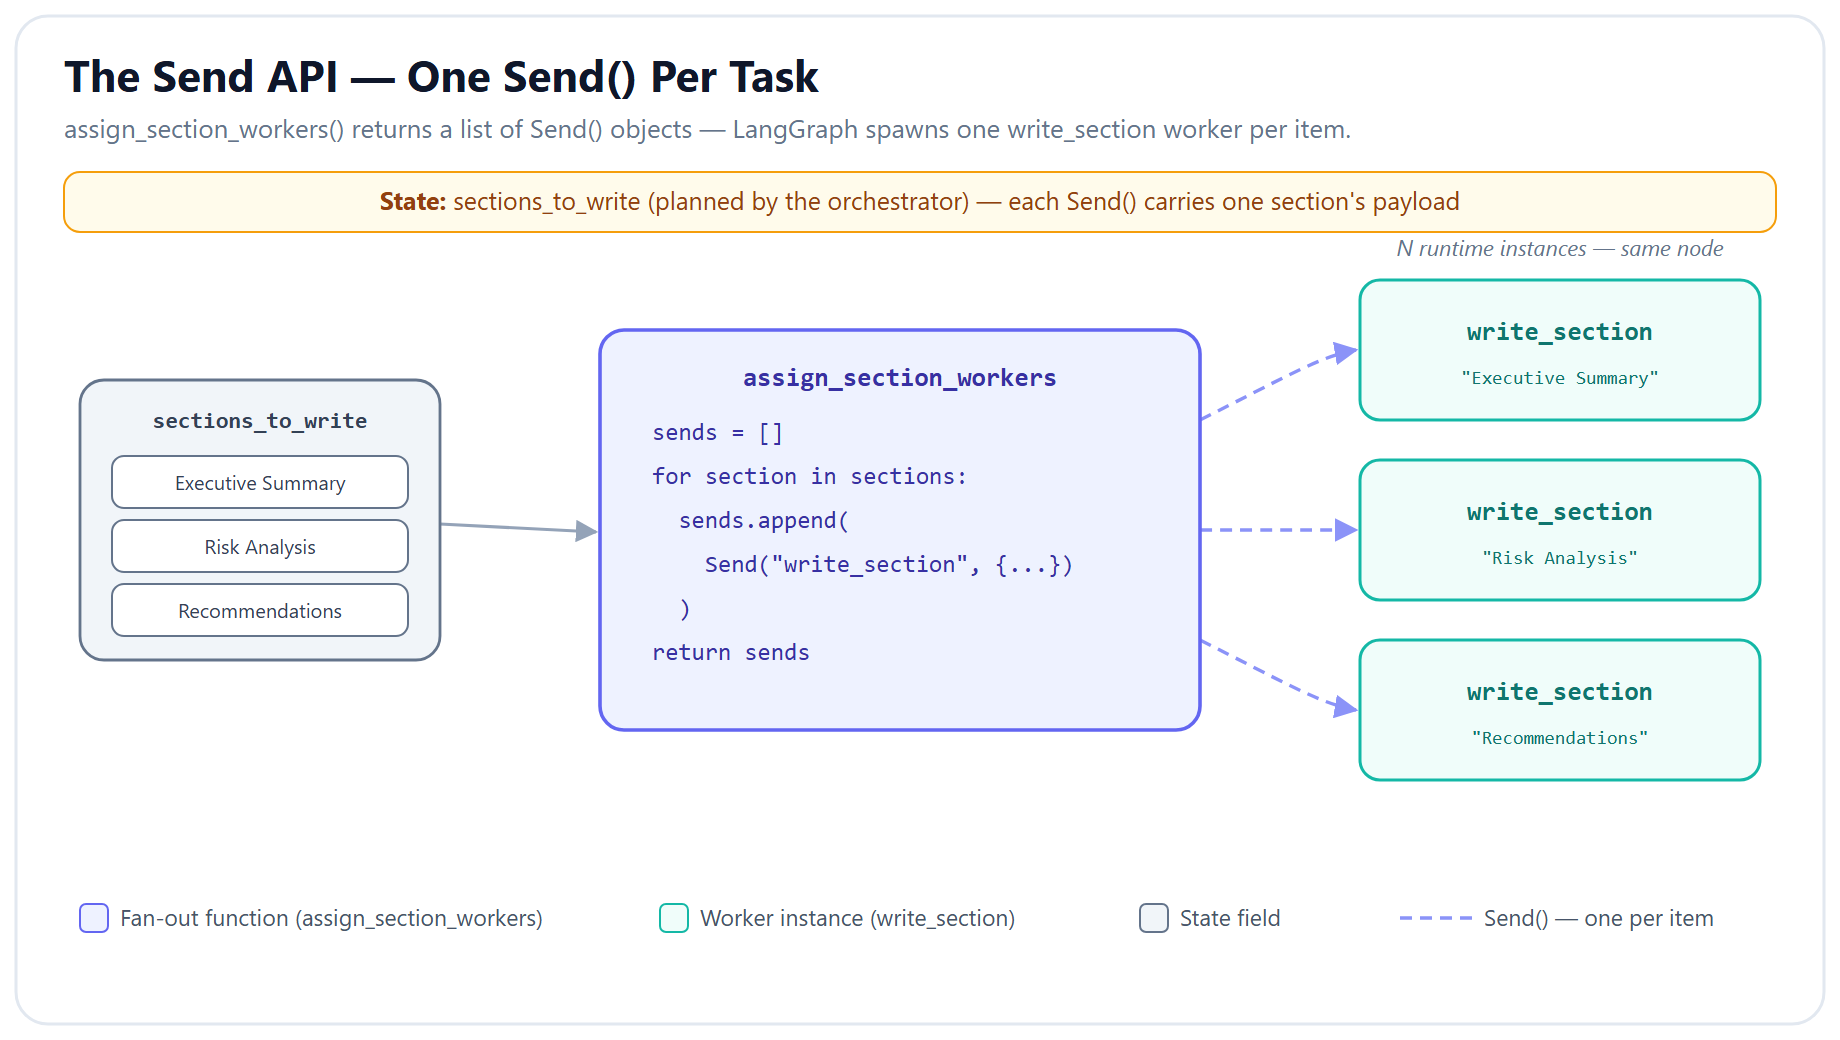

**Figure — The Send API, mechanically.** `assign_section_workers()` returns one `Send("write_section", {...})` per planned section; LangGraph spawns a parallel `write_section` worker instance for each item.

In [17]:
from langgraph.types import Send

# --- State for the Send API demo ---

# Main graph state: the orchestrator and synthesizer use this
class ReportState(TypedDict):
    """Send-API report state: the topic, the planned sections and the completed drafts."""
    report_topic: str                                    # The report topic
    sections_to_write: list                              # Orchestrator decides these at runtime
    completed_sections: Annotated[list, operator.add]    # Reducer: workers append here
    final_report: str                                    # Synthesized report

# Worker state: each Send() creates a worker with this state
class SectionWorkerState(TypedDict):
    """The state one Send() call hands to a single section worker."""
    section_name: str                                    # Which section to write
    section_description: str                             # What to cover
    completed_sections: Annotated[list, operator.add]    # Worker writes result here

print("ReportState and SectionWorkerState defined.")
print("Note: Both states share the 'completed_sections' key with the same reducer.")
print("This is how workers write back to the main graph.")

ReportState and SectionWorkerState defined.
Note: Both states share the 'completed_sections' key with the same reducer.
This is how workers write back to the main graph.


### Define the Orchestrator, Worker, and Synthesizer Nodes

Three node functions for this pipeline:

1. **plan_sections**: The orchestrator — reads the topic and decides which sections to generate (this number varies by topic!)
2. **write_section**: The worker — writes one section of the report. Gets called N times via Send, once per section.
3. **synthesize_report**: The synthesizer — combines all completed sections into a final report.

In [18]:
def plan_sections(state: ReportState) -> dict:
    """Orchestrator: decide which sections to include in the report.

    The LLM dynamically plans the sections based on the topic.
    Different topics will produce different numbers of sections.
    """
    prompt = ChatPromptTemplate.from_template("""
You are a report planner. Given the topic below, plan the sections for a brief compliance report.
Return ONLY a Python list of dicts, each with 'name' and 'description' keys.
Return between 3-7 sections depending on the topic complexity.

Topic: {topic}

Example format:
[{{"name": "Executive Summary", "description": "High-level overview of findings"}},
 {{"name": "Risk Analysis", "description": "Detailed risk assessment"}}]
""")
    chain = prompt | chat_model
    result = chain.invoke({"topic": state["report_topic"]}).content

    # Parse the LLM's response into a list of section dicts
    import ast
    try:
        sections = ast.literal_eval(result.strip())
    except:
        # Fallback if parsing fails
        sections = [
            {"name": "Overview", "description": f"Overview of {state['report_topic']}"},
            {"name": "Analysis", "description": f"Detailed analysis of {state['report_topic']}"},
            {"name": "Recommendations", "description": f"Recommendations based on {state['report_topic']}"},
        ]

    print(f"Orchestrator planned {len(sections)} sections:")
    for section_number, section in enumerate(sections, 1):
        print(f"  {section_number}. {section['name']}: {section['description']}")

    return {"sections_to_write": sections}


def write_section(state: SectionWorkerState) -> dict:
    """Worker: write one section of the report.

    Each worker receives its section assignment via Send() and writes independently.
    The result is appended to completed_sections via the reducer.
    """
    prompt = ChatPromptTemplate.from_template("""
Write a concise report section (3-4 sentences) for a compliance report.

Section: {section_name}
Description: {section_description}

Write in a professional, factual tone appropriate for a regulatory compliance report.
""")
    chain = prompt | chat_model
    content = chain.invoke({
        "section_name": state["section_name"],
        "section_description": state["section_description"],
    }).content

    print(f"  [Worker] Completed: {state['section_name']}")
    return {"completed_sections": [{"name": state["section_name"], "content": content}]}


def synthesize_report(state: ReportState) -> dict:
    """Synthesizer: combine all completed sections into a final report."""
    sections_text = "\n\n".join(
        [f"## {section['name']}\n{section['content']}" for section in state["completed_sections"]]
    )
    final = f"# Compliance Report\n\n{sections_text}"
    print(f"Synthesizer combined {len(state['completed_sections'])} sections into final report.")
    return {"final_report": final}

print("All three node functions defined: plan_sections, write_section, synthesize_report")

All three node functions defined: plan_sections, write_section, synthesize_report


### The Key: Dynamic Fan-Out with `Send()`

This is the critical function. Instead of hardcoded edges, `assign_section_workers` reads the orchestrator's plan and returns a **list of `Send()` objects** — one per section. LangGraph creates that many workers dynamically.

```python
Send("write_section", {"section_name": "...", "section_description": "..."})
```

Each `Send()` targets the `write_section` node but with DIFFERENT input. All workers run in parallel.

In [19]:
def assign_section_workers(state: ReportState) -> list[Send]:
    """Dynamic fan-out: create one worker per planned section using Send().

    This is the key difference from Parts 2-4. Instead of hardcoded edges,
    we return a list of Send() objects. LangGraph creates workers at runtime.
    """
    sends = []
    for section in state["sections_to_write"]:
        sends.append(
            Send("write_section", {
                "section_name": section["name"],
                "section_description": section["description"],
            })
        )
    print(f"Fanning out to {len(sends)} parallel workers via Send API")
    return sends

### Build the Send API Graph

Notice the key difference: instead of `add_edge(START, "check_aml")` etc., we use `add_conditional_edges` with our `assign_section_workers` function that returns `Send` objects.

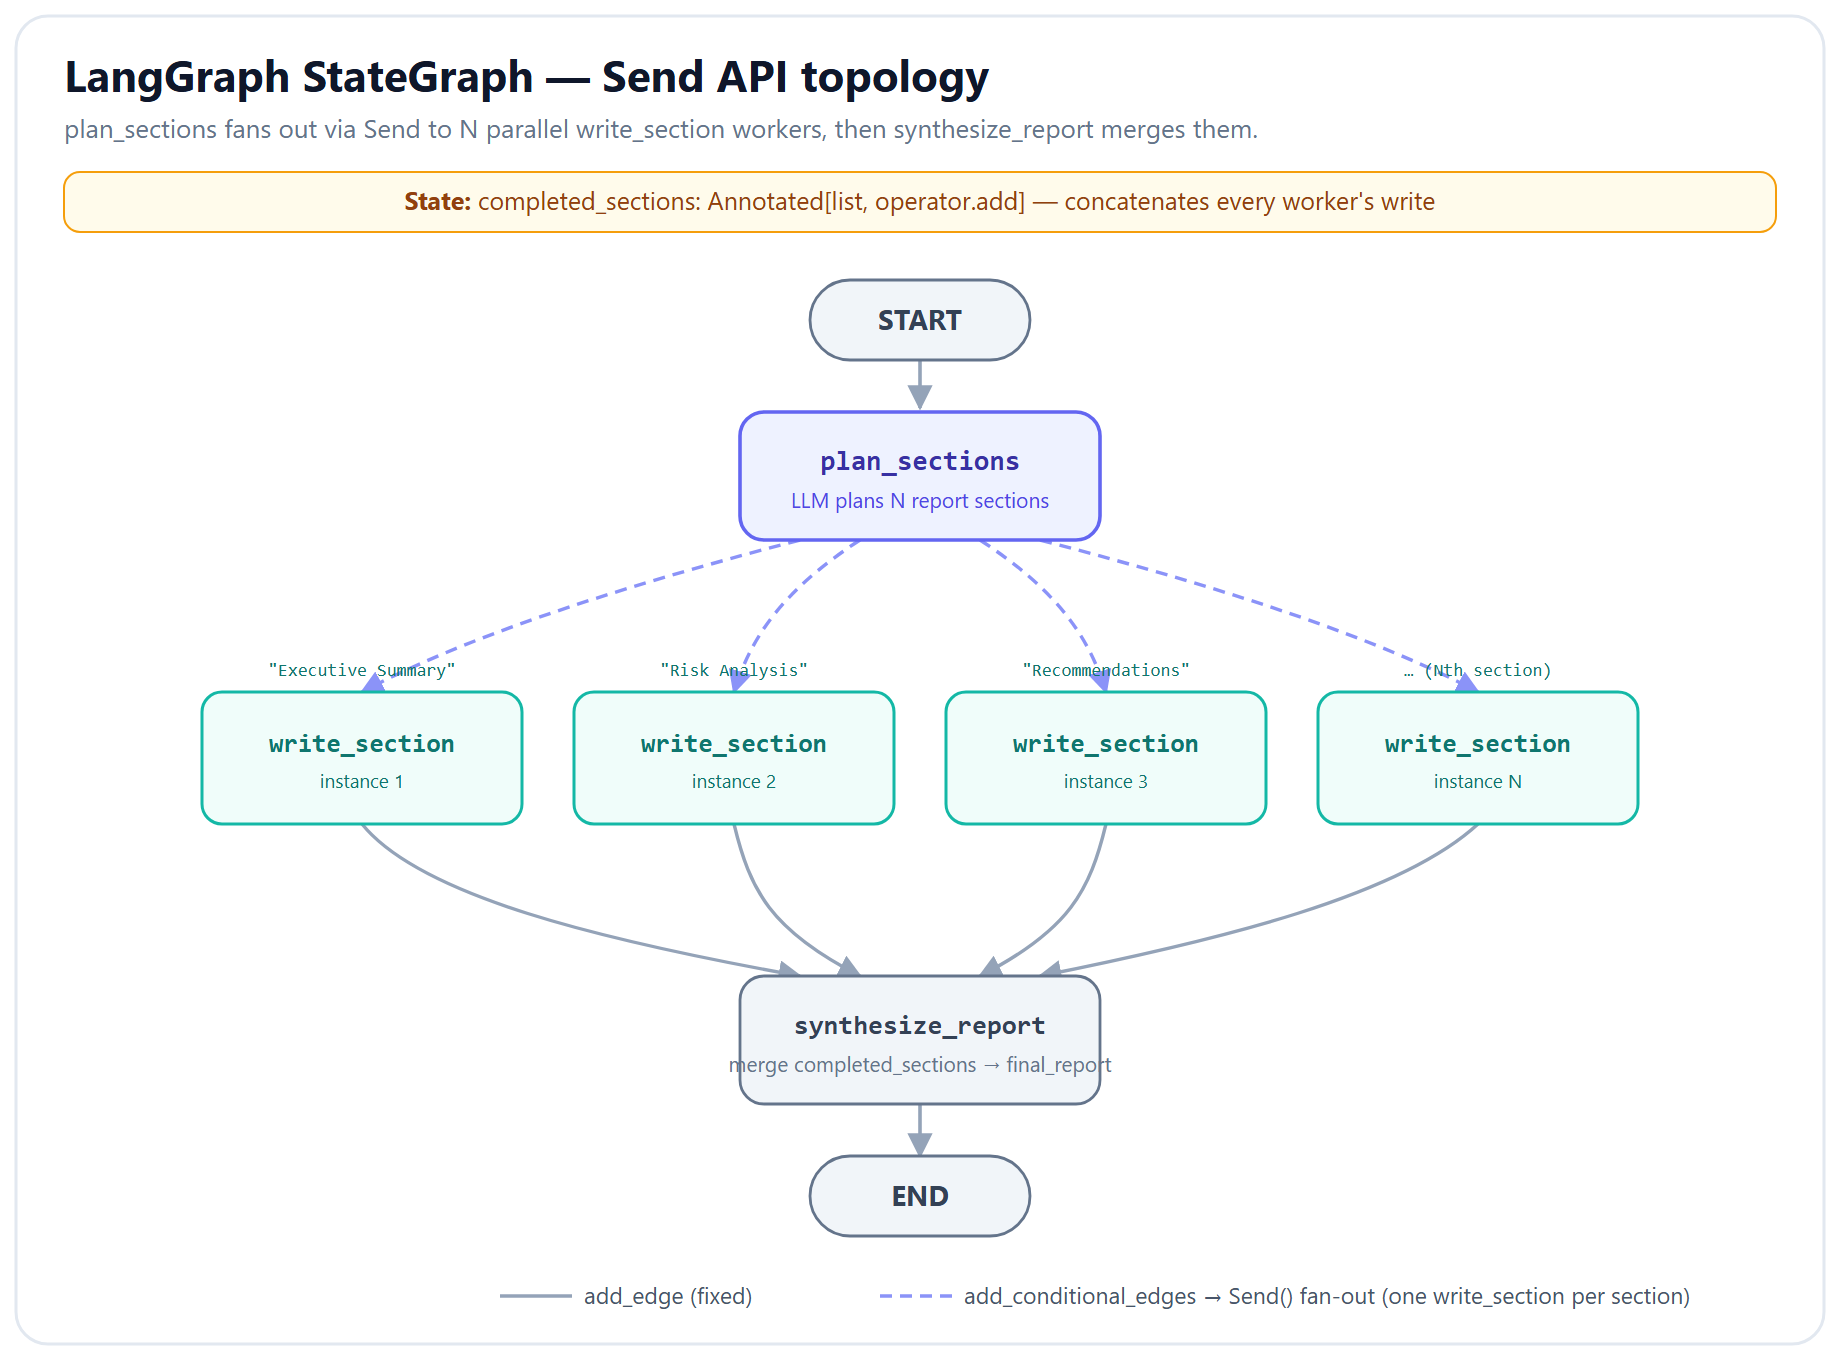

**Figure — LangGraph StateGraph topology (Send API).** `START → plan_sections → (Send fan-out) → write_section × N → synthesize_report → END`. Solid edges are fixed (`add_edge`); dashed edges are the dynamic `Send()` fan-out via `add_conditional_edges`.

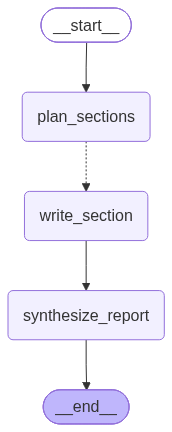

In [20]:
# Build the dynamic fan-out graph using Send API
send_builder = StateGraph(ReportState)

# Add nodes
send_builder.add_node("plan_sections", plan_sections)
send_builder.add_node("write_section", write_section)      # Single node, but Send creates N instances
send_builder.add_node("synthesize_report", synthesize_report)

# Edges
send_builder.add_edge(START, "plan_sections")

# Dynamic fan-out: plan_sections -> N x write_section (via Send)
send_builder.add_conditional_edges("plan_sections", assign_section_workers, ["write_section"])

# Fan-in: all write_section workers -> synthesize
send_builder.add_edge("write_section", "synthesize_report")
send_builder.add_edge("synthesize_report", END)

# Compile and visualize
send_graph = send_builder.compile()
display(Image(send_graph.get_graph().draw_mermaid_png()))

### Run with Two Different Topics

Watch how the orchestrator generates a **different number of sections** for each topic. This is the power of `Send` — the graph adapts at runtime.

In [21]:
# Topic 1: Simple topic — expect fewer sections
print("=" * 80)
print("TOPIC 1: Q4 2025 AML Transaction Monitoring Summary")
print("=" * 80)

result1 = send_graph.invoke({
    "report_topic": "Q4 2025 AML Transaction Monitoring Summary for a mid-size Indian bank",
    "sections_to_write": [],
    "completed_sections": [],
    "final_report": "",
})

print(f"\nFinal report has {len(result1['completed_sections'])} sections")
print("\n" + result1["final_report"][:500] + "...")

print("\n\n")

TOPIC 1: Q4 2025 AML Transaction Monitoring Summary


Orchestrator planned 7 sections:
  1. Executive Summary: Overview of AML transaction monitoring outcomes for Q4 2025
  2. Transaction Monitoring Overview: Summary of monitoring processes and tools used during the quarter
  3. Suspicious Activity Detection: Analysis of flagged transactions and patterns identified
  4. Compliance with Regulatory Requirements: Assessment of adherence to Indian AML regulations and guidelines
  5. Investigation and Reporting: Details on investigations conducted and reports filed with authorities
  6. Challenges and Improvements: Discussion of any operational challenges and planned enhancements for monitoring
  7. Conclusion and Recommendations: Summary of key findings and suggested actions for ongoing compliance
Fanning out to 7 parallel workers via Send API


  [Worker] Completed: Transaction Monitoring Overview
  [Worker] Completed: Investigation and Reporting
  [Worker] Completed: Suspicious Activity Detection
  [Worker] Completed: Challenges and Improvements


  [Worker] Completed: Executive Summary
  [Worker] Completed: Compliance with Regulatory Requirements


  [Worker] Completed: Conclusion and Recommendations
Synthesizer combined 7 sections into final report.

Final report has 7 sections

# Compliance Report

## Executive Summary
**Executive Summary**

During Q4 2025, the AML transaction monitoring system reviewed over 1.2 million transactions, identifying 1,450 alerts for further investigation. Of these, 320 cases were escalated for enhanced due diligence, resulting in 45 confirmed suspicious activity reports (SARs) filed with regulatory authorities. The monitoring processes operated effectively, with no significant system outages or compliance breaches reported during the perio...





In [22]:
# Topic 2: Complex topic — expect more sections
print("=" * 80)
print("TOPIC 2: Full Regulatory Examination Readiness Assessment")
print("=" * 80)

result2 = send_graph.invoke({
    "report_topic": "Full regulatory examination readiness assessment covering AML, KYC, sanctions, fraud prevention, and remediation tracking for OCC quarterly examination",
    "sections_to_write": [],
    "completed_sections": [],
    "final_report": "",
})

print(f"\nFinal report has {len(result2['completed_sections'])} sections")
print("\n" + result2["final_report"][:500] + "...")

TOPIC 2: Full Regulatory Examination Readiness Assessment


Orchestrator planned 7 sections:
  1. Executive Summary: Overview of the readiness assessment and key findings across all regulatory areas.
  2. AML Compliance Assessment: Evaluation of anti-money laundering policies, procedures, and controls.
  3. KYC Procedures Review: Assessment of customer identification and verification processes.
  4. Sanctions Compliance Evaluation: Review of sanctions screening and adherence to regulatory requirements.
  5. Fraud Prevention Controls: Analysis of fraud detection and prevention mechanisms in place.
  6. Remediation Tracking and Reporting: Status update on remediation efforts and tracking of outstanding issues.
  7. Recommendations and Action Plan: Suggested improvements and next steps to enhance examination readiness.
Fanning out to 7 parallel workers via Send API


  [Worker] Completed: Executive Summary
  [Worker] Completed: Fraud Prevention Controls
  [Worker] Completed: Recommendations and Action Plan
  [Worker] Completed: Remediation Tracking and Reporting
  [Worker] Completed: KYC Procedures Review


  [Worker] Completed: AML Compliance Assessment
  [Worker] Completed: Sanctions Compliance Evaluation
Synthesizer combined 7 sections into final report.

Final report has 7 sections

# Compliance Report

## Executive Summary
Executive Summary

The readiness assessment evaluated the organization’s compliance posture across all applicable regulatory areas, identifying strengths and areas requiring improvement. Key findings indicate overall adherence to core requirements, with specific gaps noted in data privacy controls and documentation practices. Remediation plans are recommended to address these deficiencies to ensure full regulatory compliance and mitigate potential risks....


---

## Part 6: Empirical Cost & Latency Analysis — 4 Parallel vs 4 Sequential

We've **claimed** that parallelization speeds things up. Now let's **prove it** with real numbers. We fire **the same 4 LLM calls** in two ways and measure wall-clock time + token usage:

1. **Sequential.** A linear graph: `START → call1 → call2 → call3 → call4 → END`.
2. **Parallel.** A fan-out graph: `START → [call1, call2, call3, call4] → aggregator → END`.

**Important:** total **input tokens** are identical in both modes (same prompts, same context). Only **wall-clock latency** changes — provider rate limits and your async I/O are the only things parallelization buys you. Output tokens are also identical because we're calling the same model with the same prompts.

> **Caveat.** This is a wall-clock benchmark, not a stress test. Provider-side queuing, network jitter, > and the GIL all add noise — run 3+ times and report the median. The ratio is what matters, not the absolute numbers.


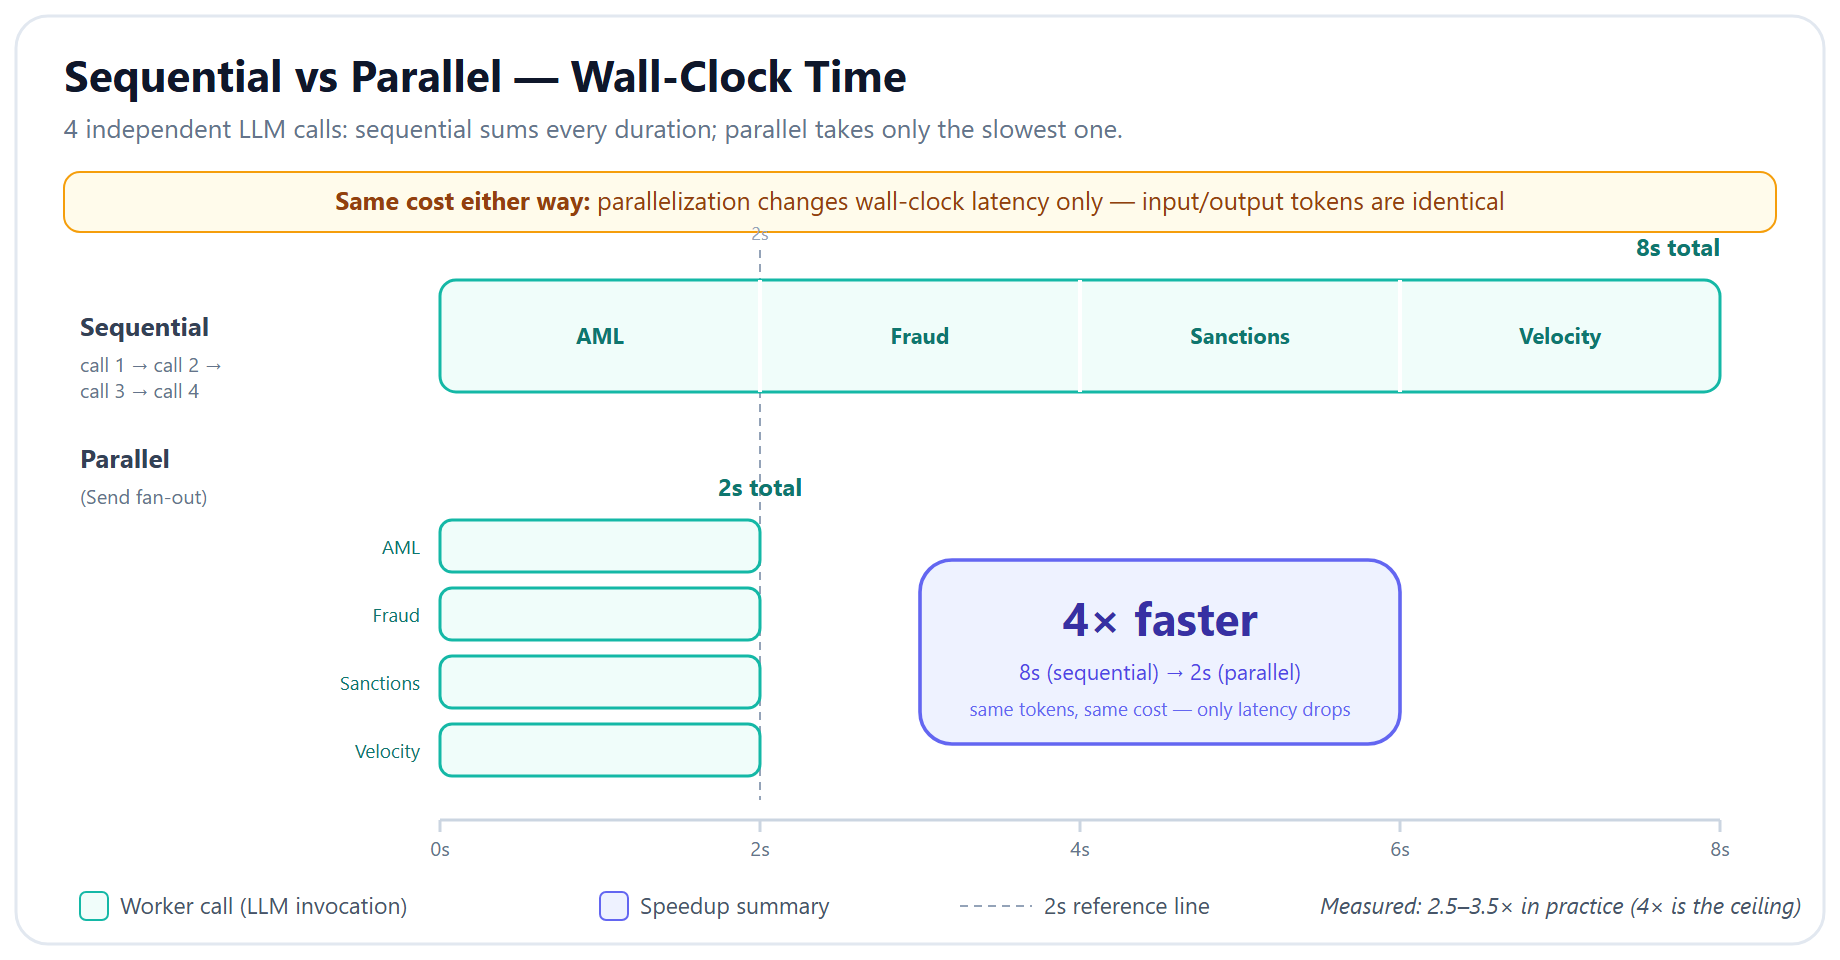

**Figure — Sequential vs parallel wall-clock time (illustrative).** The same four LLM calls take ~8s in sequence but only ~2s (the slowest call) when fanned out in parallel — tokens and cost stay identical; only latency changes. The cells below measure it for real.

In [23]:
import time
import operator
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI

# Single LLM instance reused across both pipelines (same model, same temp).
bench_llm = ChatOpenAI(model='gpt-4.1-mini', temperature=0)

# 4 distinct prompts — independent of each other.
BENCH_PROMPTS = [
    'In one sentence, explain what AML (Anti-Money Laundering) screening checks for.',
    'In one sentence, explain what KYC (Know Your Customer) verification involves.',
    'In one sentence, explain what sanctions screening checks against.',
    'In one sentence, explain what PEP (Politically Exposed Person) screening flags.',
]

class BenchState(TypedDict):
    """Benchmark state: every node's answer plus the input and output token counts."""
    answers: Annotated[list[str], operator.add]
    tokens_in: Annotated[int, operator.add]
    tokens_out: Annotated[int, operator.add]

def make_node(prompt: str):
    """Return a graph node that sends `prompt` to the benchmark model once."""
    def _node(_state: BenchState) -> dict:
        """Call the benchmark model with this node's prompt and record answer and tokens."""
        response = bench_llm.invoke(prompt)
        usage = response.usage_metadata or {}
        return {
            'answers':   [response.content],
            'tokens_in': usage.get('input_tokens', 0),
            'tokens_out': usage.get('output_tokens', 0),
        }
    _node.__name__ = f'node_{abs(hash(prompt)) % 10_000}'
    return _node


In [24]:
# ─── Pipeline 1: Sequential (linear) ──────────────────────────────────
sequential_builder = StateGraph(BenchState)
sequential_nodes = [make_node(prompt_text) for prompt_text in BENCH_PROMPTS]
for node_index, node_function in enumerate(sequential_nodes):
    sequential_builder.add_node(f'seq_{node_index}', node_function)
sequential_builder.add_edge(START, 'seq_0')
for node_index in range(len(sequential_nodes) - 1):
    sequential_builder.add_edge(f'seq_{node_index}', f'seq_{node_index+1}')
sequential_builder.add_edge(f'seq_{len(sequential_nodes)-1}', END)
sequential_graph = sequential_builder.compile()

# ─── Pipeline 2: Parallel (fan-out / fan-in) ─────────────────────────
par_builder = StateGraph(BenchState)
par_nodes = [make_node(prompt_text) for prompt_text in BENCH_PROMPTS]
for node_index, node_function in enumerate(par_nodes):
    par_builder.add_node(f'par_{node_index}', node_function)
for node_index in range(len(par_nodes)):
    par_builder.add_edge(START, f'par_{node_index}')
    par_builder.add_edge(f'par_{node_index}', END)
par_graph = par_builder.compile()

print('Built sequential and parallel benchmark graphs.')


Built sequential and parallel benchmark graphs.


In [25]:
# ─── Run both and time them ───────────────────────────────────────────
init_state: BenchState = {'answers': [], 'tokens_in': 0, 'tokens_out': 0}

start_time = time.perf_counter()
sequential_result = sequential_graph.invoke(init_state)
sequential_latency = time.perf_counter() - start_time

start_time = time.perf_counter()
par_result = par_graph.invoke(init_state)
par_latency = time.perf_counter() - start_time

print('=' * 70)
print(f'Sequential (4 calls) → wall-clock {sequential_latency:6.2f} s · '
      f'in {sequential_result["tokens_in"]:>4} tok · out {sequential_result["tokens_out"]:>4} tok')
print(f'Parallel   (4 calls) → wall-clock {par_latency:6.2f} s · '
      f'in {par_result["tokens_in"]:>4} tok · out {par_result["tokens_out"]:>4} tok')
print('=' * 70)
speedup = sequential_latency / par_latency if par_latency > 0 else float('inf')
print(f'Speedup: {speedup:.2f}× (theoretical max ~ 4×; expect 2.5–3.5× in practice)')
print(f'Token cost: identical ({sequential_result["tokens_in"]} in + {sequential_result["tokens_out"]} out either way)')
print()
print('TAKEAWAY: parallelization buys you wall-clock latency, not token cost.')
print('When wall-clock matters (user-facing chat, real-time decisions), fan-out wins.')
print('When throughput matters (batch ETL), fan-out helps less — provider rate limits dominate.')


Sequential (4 calls) → wall-clock   3.61 s · in   92 tok · out  114 tok
Parallel   (4 calls) → wall-clock   1.04 s · in   92 tok · out  115 tok
Speedup: 3.47× (theoretical max ~ 4×; expect 2.5–3.5× in practice)
Token cost: identical (92 in + 114 out either way)

TAKEAWAY: parallelization buys you wall-clock latency, not token cost.
When wall-clock matters (user-facing chat, real-time decisions), fan-out wins.
When throughput matters (batch ETL), fan-out helps less — provider rate limits dominate.


### When parallelization is NOT a win

- **Provider rate limits.** If the upstream LLM API caps you at 4 RPM, parallelizing 4 calls just means you wait at the same rate-limit boundary.
- **Single-tenant batch jobs.** Throughput-bound work — each request gets the same total CPU + token budget; the scheduling overhead can dominate.
- **Short calls (<200 ms).** The fan-out / fan-in scheduling overhead can be > 50% of the saving. Profile before parallelizing.
- **Dependent steps masquerading as independent.** If branch B silently needs branch A's output, parallel execution will give you stale or missing data — typically a state-shape bug, not a perf gain.
- **High-cardinality fan-out (1000+ branches).** You'll exhaust the executor pool. Use bounded concurrency or batch the work into chunks.


---
## 7. Conclusion & Key Takeaways

### What We Covered

| Concept | Takeaway |
|---|---|
| **Linear baseline** | Wall-clock = sum of node times. The yardstick to beat. |
| **Static fan-out / fan-in** | One source node → N parallel edges → one sink node. Best when N is fixed at compile time. |
| **Reducers for parallel writes** | `Annotated[list, operator.add]` and friends are how concurrent partial updates merge deterministically |
| **Dynamic fan-out with `Send`** | Worker count and per-worker payload are computed at runtime. Best when N depends on the input. |
| **`Send` vs `RunnableParallel`** | `RunnableParallel` is LCEL static-dict fan-out (no state, no checkpointing). `Send` is graph-runtime, stateful, checkpointable. |
| **Empirical speedup (this lab)** | 4 parallel calls completed in ~max(t_i) instead of ~sum(t_i) — typically 2.5–3.5× speedup on 4 branches. |
| **Cost stays identical** | Parallelization buys latency, not tokens. Output and input tokens are unchanged. |

**Next Lab:** Lab 7.4 — Corrective & Adaptive RAG in LangGraph 🔁


> ⏭️ **After the session.** This section is not run live in the workshop. Work through it afterwards, top to bottom.

## 8. Stretch Exercise (Optional)

1. Add **per-branch error handling** — wrap one node so it raises ~30% of the time, then add a `default` aggregator that records partial results when a branch fails. (Hint: try `RunnableConfig.configurable` and a fallback aggregator pattern.)
2. Convert the **dynamic Send** report-writer to **bounded concurrency** — never run more than 3 workers at once even if the planner asks for 10. (Hint: `RunnableConfig.max_concurrency` or a semaphore in the worker.)
3. Run the cost-analysis benchmark **5 times** and report median + p90 latency — single runs are noisy.
4. Replicate the parallel compliance pipeline using **LCEL `RunnableParallel`** instead of LangGraph. Compare developer ergonomics and where each shines.
5. Add a **timing log** to every node by writing `node_started_at` / `node_finished_at` to state. Plot the per-node Gantt chart with matplotlib.
